In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("generated_crystals_cifs/voltage_analysis.csv")
df_guide2 = pd.read_csv("../guide2_Li02_Na2_2048/generated_crystals_cifs/voltage_analysis.csv")
df_old100 = pd.read_csv("../../600epochs_LiNadiff/guide4_Li02_Na2/generated_crystals_cifs/voltage_analysis.csv")
df_old2048 = pd.read_csv("../../600epochs_LiNadiff/guide4_Li02_Na2_2048/generated_crystals_cifs/voltage_analysis.csv")
df_train = pd.read_csv("/home/ilgar/MatterGen_extractLi/datasets/li_data_20/train.csv")
df_train_diff_add1 = pd.read_csv("/home/ilgar/MatterGen_extractLi/datasets/li_data_20_diff_add1/train.csv")

In [3]:
df

,pretty_formula,filename,num_atoms,host_energy,Li_energy,Na_energy,host_energy_per_atom,Li_energy_per_atom,Na_energy_per_atom,Li_voltage,Na_voltage,host_structure,Li_structure,Na_structure
0,LiCr2(NiO3)2,gen_0,11.0,-63.423657,-68.239624,-65.725424,-6.342366,-6.203602,-5.975039,-0.127233,-1.717533,# generated using pymatgen\ndata_CrNiO3\n_symm...,# generated using pymatgen\ndata_LiCr2(NiO3)2\...,# generated using pymatgen\ndata_NaCr2(NiO3)2\...
1,LiCr3NiO6,gen_1,11.0,-70.577127,-76.128480,-74.339858,-7.057713,-6.920771,-6.758169,0.608153,-0.256569,# generated using pymatgen\ndata_Cr3NiO6\n_sym...,# generated using pymatgen\ndata_LiCr3NiO6\n_s...,# generated using pymatgen\ndata_NaCr3NiO6\n_s...
2,CrO,gen_10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Li2Cr5CoO10,gen_100,18.0,-118.153517,-127.345749,-122.533582,-7.384595,-7.074764,-6.807421,-0.347084,-1.829268,# generated using pymatgen\ndata_Cr5CoO10\n_sy...,# generated using pymatgen\ndata_Li2Cr5CoO10\n...,# generated using pymatgen\ndata_Na2Cr5CoO10\n...
4,LiCr3O4,gen_1000,8.0,-51.929417,-56.790063,-55.431397,-7.418488,-7.098758,-6.928925,-0.082554,-0.517320,# generated using pymatgen\ndata_Cr3O4\n_symme...,# generated using pymatgen\ndata_LiCr3O4\n_sym...,# generated using pymatgen\ndata_NaCr3O4\n_sym...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,LiCrSbO4,gen_995,7.0,-41.355104,-44.341178,-43.929250,-6.892517,-6.334454,-6.275607,-1.957126,-1.445154,# generated using pymatgen\ndata_CrSbO4\n_symm...,# generated using pymatgen\ndata_LiCrSbO4\n_sy...,# generated using pymatgen\ndata_NaCrSbO4\n_sy...
2044,LiBeCr2(NiO2)4,gen_996,16.0,-89.568960,-93.607848,-91.748285,-5.971264,-5.850491,-5.734268,-0.904312,-1.839975,# generated using pymatgen\ndata_BeCr2(NiO2)4\...,# generated using pymatgen\ndata_LiBeCr2(NiO2)...,# generated using pymatgen\ndata_NaBeCr2(NiO2)...
2045,CrO2,gen_997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2046,LiCrO2,gen_998,8.0,-44.370599,-54.303292,-50.779477,-7.395100,-6.787911,-6.347435,0.023146,-0.814861,# generated using pymatgen\ndata_CrO2\n_symmet...,# generated using pymatgen\ndata_LiCrO2\n_symm...,# generated using pymatgen\ndata_NaCrO2\n_symm...


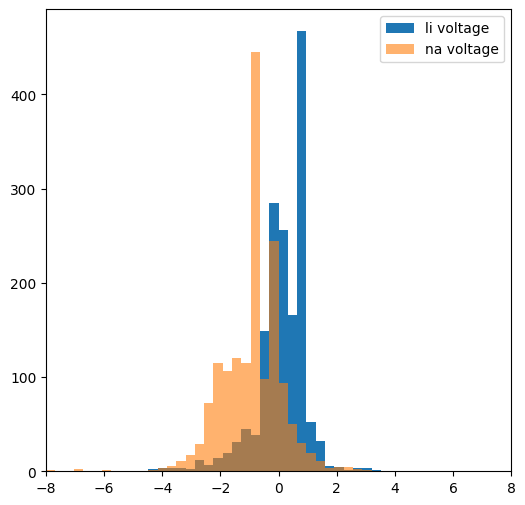

In [4]:
plt.figure(figsize=(6,6))
plt.hist(df['Li_voltage'],label="li voltage",bins=50,range=(-8,8))
plt.hist(df['Na_voltage'],label="na voltage",bins=50,range=(-8,8),alpha=0.6)
plt.xlim(-8,8)
plt.legend()
plt.show()

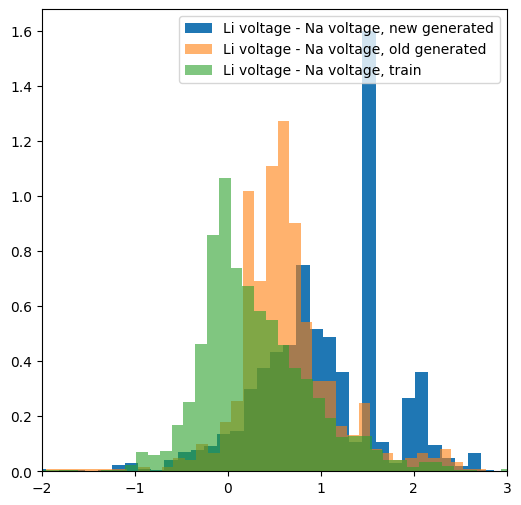

In [8]:
plt.figure(figsize=(6,6))
plt.hist(df['Li_voltage']-df['Na_voltage'],label="Li voltage - Na voltage, new generated",bins=50,density=True)
plt.hist(df_old2048['Li_voltage']-df_old2048['Na_voltage'],label="Li voltage - Na voltage, old generated",bins=50,alpha=0.6,density=True)
plt.hist(df_train['Li_voltage']-df_train['Na_voltage'],label="Li voltage - Na voltage, train",bins=50,alpha=0.6,density=True)
plt.xlim(-2,3)
plt.legend()
plt.show()

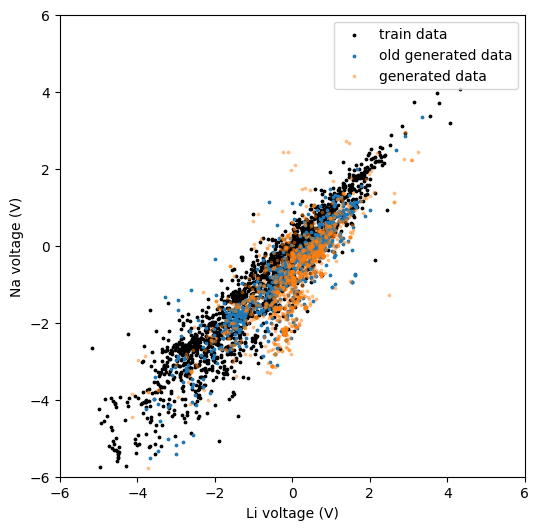

In [6]:
plt.figure(figsize=(6,6))
plt.scatter(df_train['Li_voltage'],df_train['Na_voltage'],s=3,label="train data",c='k')
plt.scatter(df_old2048['Li_voltage'],df_old2048['Na_voltage'],s=3,label="old generated data")
plt.scatter(df['Li_voltage'],df['Na_voltage'],s=3,label="generated data", alpha=0.4)
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.xlabel("Li voltage (V)")
plt.ylabel("Na voltage (V)")
plt.legend()
plt.show()


In [9]:
df_to_add = df[['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'Li_structure']]
df_to_add.columns = ['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'cif']
df_to_add['Na_voltage'] = df_to_add['Li_voltage'] - df_to_add['Na_voltage']

/tmp/ipykernel_4052993/4151272627.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_add['Na_voltage'] = df_to_add['Li_voltage'] - df_to_add['Na_voltage']


In [10]:
df_guide2_add = df_guide2[['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'Li_structure']]
df_guide2_add.columns = ['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'cif']
df_guide2_add['Na_voltage'] = df_guide2_add['Li_voltage'] - df_guide2_add['Na_voltage'] 

/tmp/ipykernel_4052993/2297631427.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_guide2_add['Na_voltage'] = df_guide2_add['Li_voltage'] - df_guide2_add['Na_voltage']


In [11]:
df_merged = pd.concat([df_train_diff_add1,df_to_add,df_guide2_add],ignore_index=True)

In [12]:
# remove nan rows except if Nan is only in 'material_id' column
df_merged_cleaned = df_merged.dropna(subset=['Li_voltage', 'Na_voltage', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom'])

In [14]:
df_merged_cleaned.to_csv("train_extended_cleaned.csv",index=False)

In [13]:
df_merged_cleaned

,pretty_formula,material_id,num_atoms,host_energy_per_atom,Li_energy_per_atom,Na_energy_per_atom,Li_voltage,Na_voltage,cif
0,Rb2LiBi2O5,mp-975106,10.0,-5.001463,-4.840352,-4.775824,-1.552852,-0.278626,# generated using pymatgen\ndata_Rb2LiBi2O5\n_...
1,LiVCl2O,mp-1216404,5.0,-5.365562,-5.168905,-4.801249,-0.560927,0.914376,# generated using pymatgen\ndata_LiVCl2O\n_sym...
2,LiScTl(MoO4)2,mp-19450,13.0,-7.246476,-6.905751,-6.844393,-2.126157,-0.126252,# generated using pymatgen\ndata_LiScTl(MoO4)2...
3,Li4Cr3FeO8,mp-756058,16.0,-6.821576,-6.671563,-6.509723,0.678274,0.370821,# generated using pymatgen\ndata_Li4Cr3FeO8\n_...
4,Ba4Li(Co2O5)2,mp-1076439,19.0,-6.059365,-5.934136,-5.872205,-1.263181,0.252789,# generated using pymatgen\ndata_Ba4Li(Co2O5)2...
...,...,...,...,...,...,...,...,...,...
6841,LiCr2O3,NaN,6.0,-7.539572,-7.042780,-6.752984,-0.384378,0.814879,# generated using pymatgen\ndata_LiCr2O3\n_sym...
6842,LiCrO2,NaN,4.0,-7.040741,-6.701296,-6.104033,0.739762,1.465153,# generated using pymatgen\ndata_LiCrO2\n_symm...
6843,LiCr(Ni2O3)2,NaN,12.0,-5.461806,-5.490173,-5.363914,0.859008,0.591206,# generated using pymatgen\ndata_LiCr(Ni2O3)2\...
6846,LiCrCoO3,NaN,12.0,-6.880770,-6.592878,-6.347169,0.210218,0.550354,# generated using pymatgen\ndata_LiCrCoO3\n_sy...
